# Published world-model agents on Krull — DIAMOND & IRIS vs our DQN stack

**2026-08-23 · single GB10 GPU · pretrained checkpoints evaluated under OUR seeded protocol**

Goal: put the EfficientRainbow ± FHR results next to *published, pretrained*
Atari-100k agents evaluated on the **same 32 seeded full-game episodes**
(reset seeds 1000+i) instead of only comparing against paper numbers.

**Why not MuZero/EfficientZero?** No MCTS-family repo publishes a Krull
checkpoint at any budget (checked 2026-08-23): LightZero's HuggingFace zoo has
only Pong/Breakout/MsPacman; EfficientZero v1/v2 release no weights;
muzero-general has only CartPole/LunarLander. The closest public,
per-game-checkpointed Atari-100k agents are Eloi Alonso's **world-model**
agents, which release **all 26 games including Krull**:

| agent | idea | published Krull (100k) | license |
|---|---|---|---|
| **IRIS** (ICLR 2023) | VQ-tokenizer + transformer world model; LSTM actor-critic acts on tokenizer reconstructions | 6616.4 | GPL-3.0 |
| **DIAMOND** (NeurIPS 2024) | diffusion world model; LSTM actor-critic acts on raw 64×64 RGB frames | 8610.1 | MIT |

Both are **world-model/imagination agents without lookahead search** — that is
the honest label for this comparison. Each is evaluated with **its own**
published env contract and action rule (see `worldmodel_eval.py`): DIAMOND
samples its policy (test ε=0) on [-1,1]-scaled frames; IRIS samples at
temperature 0.5 through its tokenizer round-trip. Ours act ε=0.001-greedy on
84×84 grayscale stacks. All four see full games, raw scores, same reset seeds.

## 0 · Fetch checkpoints & run the seeded evaluations

Idempotent: repos/checkpoints are only downloaded and evaluations only run if
missing. Heavy lifting lives in `worldmodel_eval.py` next to this notebook —
one subprocess per model (the two repos have clashing module names).
DIAMOND ≈ 4 min, IRIS ≈ 15 min for 32 episodes + a video each on the GB10.

In [1]:
import json, pathlib, subprocess, sys

HERE = pathlib.Path.cwd()
EXT = HERE / "cached" / "external"
EVAL = HERE / "cached" / "worldmodel_eval"
EXT.mkdir(parents=True, exist_ok=True)

def sh(*cmd):
    print("$", " ".join(map(str, cmd)), flush=True)
    subprocess.run(list(map(str, cmd)), check=True)

if not (EXT / "diamond").is_dir():
    sh("git", "clone", "--depth", "1",
       "https://github.com/eloialonso/diamond", EXT / "diamond")
if not (EXT / "iris").is_dir():
    sh("git", "clone", "--depth", "1",
       "https://github.com/eloialonso/iris", EXT / "iris")

from huggingface_hub import hf_hub_download, snapshot_download
if not (EXT / "hf_diamond" / "atari_100k" / "models" / "Krull.pt").exists():
    hf_hub_download("eloialonso/diamond", "atari_100k/models/Krull.pt",
                    local_dir=EXT / "hf_diamond")
    snapshot_download("eloialonso/diamond",
                      allow_patterns=["atari_100k/config/**"],
                      local_dir=EXT / "hf_diamond")
if not (EXT / "hf_iris" / "pretrained_models" / "Krull.pt").exists():
    hf_hub_download("eloialonso/iris", "pretrained_models/Krull.pt",
                    local_dir=EXT / "hf_iris")

for model in ("diamond", "iris"):
    if (EVAL / f"{model}_krull.json").exists():
        print(f"{model}: cached eval found — skipping")
    else:
        sh(sys.executable, HERE / "worldmodel_eval.py", model, "--video")

diamond: cached eval found — skipping
iris: cached eval found — skipping


/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Same-seed comparison — our arms vs the pretrained world models

Bars: mean over the 32 seeded episodes (whiskers = ±1 std over episodes; our
arms additionally average their per-seed means, whiskers = seed range of
means). Pale bars behind DIAMOND/IRIS: their published means (30+ seeds /
their own eval draw) for reference.

agent                                            mean   median     std    HNS
IRIS                                           8694.7   9250.0  1279.9  6.648 (published 6,616.4)
DIAMOND                                        9848.4  10440.0  1528.1  7.729 (published 8,610.1)
baseline                                       4212.2                   2.449
exp3                                           5035.6                   3.220


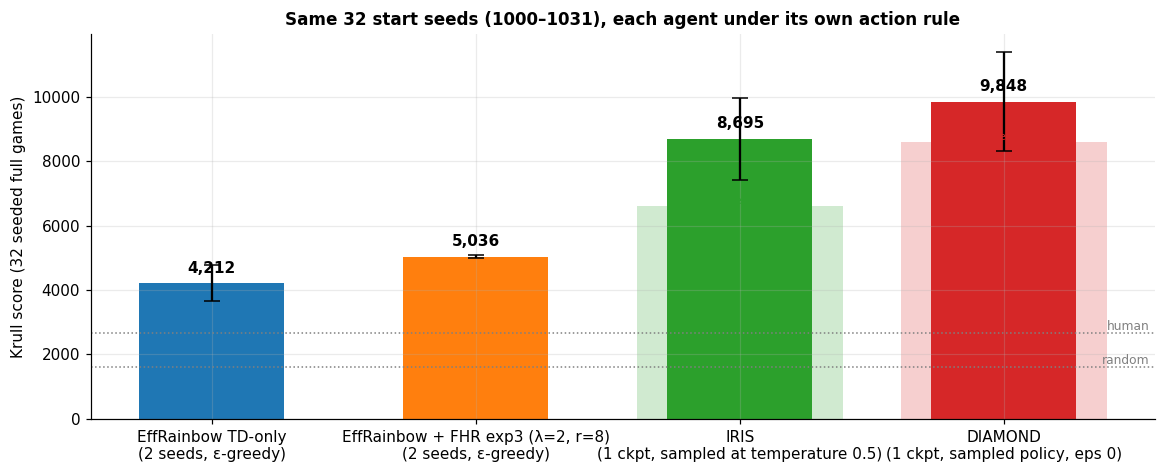

In [2]:
import numpy as np, yaml
import matplotlib.pyplot as plt

SRC = HERE.parents[2] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from analysis.atari100k import hns

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})

CFG = yaml.safe_load(open(HERE / "config_effrainbow_100k.yaml"))
FHR_EXPS = {str(k): v for k, v in
            (CFG["experiment"].get("fhr_experiments") or {}).items()}
SEEDS = [str(s) for s in
         (CFG["experiment"].get("seeds") or [CFG["experiment"]["seed"]])]
MAN = json.load(open(HERE / "cached" / "effrainbow100k_runs_manifest.json"))

rows = []                # (label, mean, err_lo, err_hi, colour, note)
for arm in ["baseline"] + [f"exp{k}" for k in sorted(FHR_EXPS, key=int)]:
    means = []
    for s in SEEDS:
        rel = MAN["runs"].get(arm, {}).get(s)
        if rel:
            means.append(json.load(open(HERE / rel / "eval_summary.json"))["mean"])
    if not means:
        continue
    ov = MAN.get("overrides", {}).get(arm, FHR_EXPS.get(arm[3:], {}))
    lab = ("EffRainbow TD-only" if arm == "baseline" else
           f"EffRainbow + FHR {arm} (λ={ov.get('fhr_weight')}, r={ov.get('fhr_order')})")
    m = float(np.mean(means))
    rows.append((f"{lab}\n({len(means)} seeds, ε-greedy)", m,
                 m - min(means), max(means) - m,
                 "tab:blue" if arm == "baseline" else "tab:orange", None))

PUBLISHED = {"diamond": 8610.1, "iris": 6616.4}
for model, colour in (("iris", "tab:green"), ("diamond", "tab:red")):
    p = EVAL / f"{model}_krull.json"
    if not p.exists():
        continue
    r = json.load(open(p))
    sc = np.array(r["scores"])
    rows.append((f"{model.upper()}\n(1 ckpt, {r['protocol']})",
                 sc.mean(), sc.std(ddof=1), sc.std(ddof=1),
                 colour, PUBLISHED[model]))

fig, ax = plt.subplots(figsize=(1.5 + 2.3 * len(rows), 4.4))
for i, (lab, m, lo, hi, col, pub) in enumerate(rows):
    if pub is not None:
        ax.bar(i, pub, color=col, alpha=0.22, width=0.78)
        ax.annotate(f"published {pub:,.0f}", (i, pub), ha="center",
                    va="bottom", fontsize=7, color=col)
    ax.bar(i, m, color=col, width=0.55, yerr=[[lo], [hi]], capsize=5)
    ax.annotate(f"{m:,.0f}", (i, m), ha="center", va="bottom",
                fontweight="bold", xytext=(0, 5), textcoords="offset points")
for y, lab in ((1598.0, "random"), (2665.5, "human")):
    ax.axhline(y, color="gray", ls=":", lw=1)
    ax.annotate(lab, (0.995, y), xycoords=("axes fraction", "data"),
                ha="right", va="bottom", fontsize=8, color="gray")
ax.set(xticks=range(len(rows)), xticklabels=[r[0] for r in rows],
       ylabel="Krull score (32 seeded full games)",
       title="Same 32 start seeds (1000–1031), each agent under its own action rule")
plt.tight_layout()

print(f"{'agent':44s} {'mean':>8s} {'median':>8s} {'std':>7s}    HNS")
for model in ("iris", "diamond"):
    p = EVAL / f"{model}_krull.json"
    if p.exists():
        r = json.load(open(p))
        print(f"{model.upper():44s} {r['mean']:8.1f} {r['median']:8.1f} "
              f"{r['std']:7.1f}  {hns(r['mean'], 'Krull'):.3f} "
              f"(published {PUBLISHED[model]:,.1f})")
for arm in ["baseline"] + [f"exp{k}" for k in sorted(FHR_EXPS, key=int)]:
    means = [json.load(open(HERE / MAN["runs"][arm][s] / "eval_summary.json"))["mean"]
             for s in SEEDS if s in MAN["runs"].get(arm, {})]
    if means:
        print(f"{arm:44s} {np.mean(means):8.1f} {'':8s} {'':7s}  "
              f"{hns(float(np.mean(means)), 'Krull'):.3f}")

**Read with care:** DIAMOND/IRIS are single published checkpoints (one
training run each) evaluated with stochastic (sampled) policies, so their
per-episode std mixes policy stochasticity with start-state variation; our
arms are ε=0.001-greedy, 2 training seeds. Observation pipelines differ by
design (64×64 RGB vs 84×84 gray stack) — the shared thing is the game, the
budget (100k env steps), full-game scoring, and the 32 reset seeds.

Both checkpoints measure **above** their published Krull means here
(DIAMOND ≈9.8k vs 8610 published, IRIS ≈8.7k vs 6616). The published numbers
average over several *training* runs (and their own eval draws), while a
released checkpoint is one — typically good — run, so this is expected, not a
protocol bug.

## 2 · Gameplay — all four policies, one representative full game each

Median-scoring episode of each agent's 32-episode eval (its own seed).
EffRainbow clips: seed-0 runs. Episode lengths are similar across all four
agents (≈1100–1500 agent steps to lose three lives) — the score gaps are
**scoring rate**, not survival: the same signature the gameplay probe found
for exp3 vs the TD baseline, taken further by the world-model agents.

In [3]:
import glob
from IPython.display import HTML

VID = HERE / "videos"
cols = [("EffRainbow TD only", "effrainbow_baseline_seed0_score*")]
cols += [(f"EffRainbow + FHR exp{k}", f"effrainbow_exp{k}_seed0_score*")
         for k in sorted(FHR_EXPS, key=int)]
cols += [("IRIS (pretrained)", "iris_score*"),
         ("DIAMOND (pretrained)", "diamond_score*")]
html = "<table><tr>"
for name, pat in cols:
    hits = sorted(glob.glob(str(VID / (pat + ".mp4"))),
                  key=lambda p: int(p.rsplit("score", 1)[-1][:-4]))
    if not hits:
        html += f"<td><b>{name}</b><br>(video pending)</td>"
        continue
    rel = pathlib.Path(hits[-1]).relative_to(HERE)
    score = pathlib.Path(hits[-1]).stem.split("score")[-1]
    html += (f"<td style='text-align:center;padding:0 10px'><b>{name}</b><br>"
             f"<span style='color:gray'>this game: {score} points</span><br>"
             f"<video src='{rel}' controls width='260'></video></td>")
html += "</tr></table>"
HTML(html)

EffRainbow TD onlythis game: 4830 points,EffRainbow + FHR exp3this game: 4560 points,IRIS (pretrained)this game: 8390 points,DIAMOND (pretrained)this game: 11480 points
